# Notebook 29

# Random Forest Optimization Experiment

This notebook investigates optimization strategies for improving the baseline Random Forest model developed in Notebook 28.

Objectives

- Improve DROWSY recall
- Improve NORMAL precision
- Preserve overall accuracy
- Analyze the effect of each optimization independently

Experiment

1. Balanced Random Forest


In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [24]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v5_lane_vehicle.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v5_lane_vehicle.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 174)
(66060, 174)


In [26]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = train_dataset["behavior"].replace(behavior_map)
test_dataset["behavior"] = test_dataset["behavior"].replace(behavior_map)

In [27]:
print(train_dataset["behavior"].value_counts())
print()
print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [28]:
ttc_columns = [
    "ttc_mean",
    "ttc_std",
    "ttc_variance",
    "ttc_min",
    "ttc_max",
    "ttc_median",
    "ttc_rms",
    "ttc_skewness",
    "ttc_kurtosis",
    "ttc_q25",
    "ttc_q75",
    "ttc_iqr"
]

for col in ttc_columns:

    if col in train_dataset.columns:

        if any(x in col for x in [
            "std",
            "variance",
            "iqr",
            "skewness",
            "kurtosis"
        ]):

            train_dataset[col] = train_dataset[col].fillna(0)
            test_dataset[col] = test_dataset[col].fillna(0)

        else:

            train_dataset[col] = train_dataset[col].fillna(100)
            test_dataset[col] = test_dataset[col].fillna(100)

train_dataset = train_dataset.fillna(0)
test_dataset = test_dataset.fillna(0)

print(train_dataset.isnull().sum().sum())
print(test_dataset.isnull().sum().sum())

0
0


In [29]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]

X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]

y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 170)
(66060, 170)


In [30]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


# Experiment 1

## Balanced Random Forest

Objective

Evaluate the effect of class balancing on the baseline Random Forest model.

Expected Improvements

- Increase DROWSY recall
- Improve NORMAL precision
- Preserve overall accuracy

In [31]:
rf_model_balanced = RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf_model_balanced.fit(
    X_train,
    y_train
)

print("Balanced Random Forest trained successfully!")

Balanced Random Forest trained successfully!


In [32]:
rf_pred_balanced = rf_model_balanced.predict(
    X_test
)

rf_pred_balanced[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
balanced_accuracy = accuracy_score(
    y_test,
    rf_pred_balanced
)

print(f"Balanced Random Forest Accuracy: {balanced_accuracy:.4f}")

Balanced Random Forest Accuracy: 0.6142


In [34]:
print(
    classification_report(
        y_test,
        rf_pred_balanced,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.89      0.73      0.80     15257
      DROWSY       0.83      0.51      0.63     36143
      NORMAL       0.35      0.75      0.48     14660

    accuracy                           0.61     66060
   macro avg       0.69      0.66      0.64     66060
weighted avg       0.74      0.61      0.64     66060



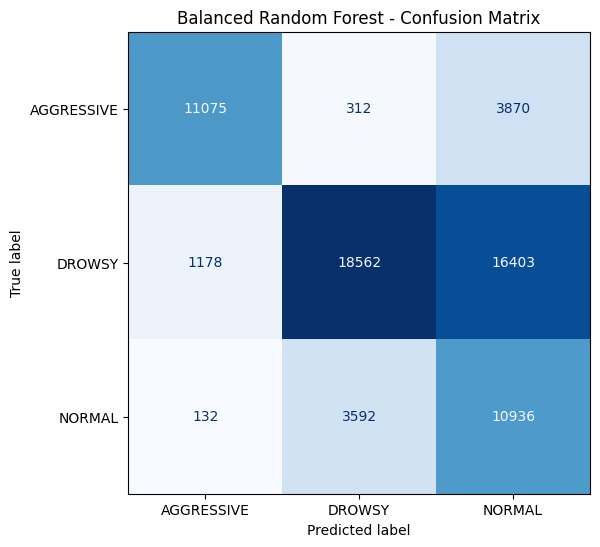

In [35]:
cm_balanced = confusion_matrix(
    y_test,
    rf_pred_balanced
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Balanced Random Forest - Confusion Matrix")
plt.show()

In [36]:
importance_balanced = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model_balanced.feature_importances_
})

importance_balanced = importance_balanced.sort_values(
    "Importance",
    ascending=False
)

importance_balanced.head(30)

,Feature,Importance
28,speed_max,0.031787
138,relative_speed_rms,0.030748
34,speed_q75,0.026789
29,speed_median,0.024989
30,speed_rms,0.024157
33,speed_q25,0.023972
24,speed_mean,0.022957
88,lane_offset_max,0.021626
94,lane_offset_q75,0.020057
27,speed_min,0.019378


## Experiment 1 Conclusion

Applying balanced class weights did not improve DROWSY recall.

Instead:

- Overall accuracy decreased.
- DROWSY recall decreased.
- NORMAL precision also decreased.

Therefore, class imbalance is unlikely to be the main cause of the misclassification between DROWSY and NORMAL.

The next experiments will focus on decision threshold optimization instead of reweighting the classes.